
# Self-contained UJI character notebook: class-conditioned style-latent autoregressive Pyro model

This notebook is designed to replace the earlier debug notebook with a stronger model while keeping the same kinds of checks:

- data loading and filtering
- plotting multiple samples before training
- overfit or few-sample scenarios
- teacher-forced next-step prediction
- rollout from a real prefix
- pure ancestral sampling
- rendered Pyro graph

Model summary:

- **Observed class label** `y` during training
- **Latent style variable** `s` per sequence
- **Autoregressive latent state** `z_t`
- **Length model** `L ~ p(L | y, s)` for full-sequence generation
- Observations per step: `[dx, dy, pen, eos]`

This notebook uses **delta coordinates** by default because they tend to work better than absolute coordinates for next-step prediction.


In [2]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import pyro
import pyro.distributions as dist
import pyro.poutine as poutine
from pyro.nn import PyroModule
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import ClippedAdam
from pyro import render_model

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
pyro.set_rng_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [3]:

# -------------------------------------------------------
# label setup
# -------------------------------------------------------
classes = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ") + list("123456789")
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
NUM_CLASSES = len(classes)

print("Number of classes:", NUM_CLASSES)
print(classes)


Number of classes: 35
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [4]:

# -------------------------------------------------------
# data helpers
# -------------------------------------------------------
def normalize_points(xy):
    xy = xy.astype(np.float32).copy()
    xy = xy - xy.mean(axis=0, keepdims=True)
    scale = np.max(np.abs(xy))
    if scale > 0:
        xy = xy / scale
    return xy


def remove_duplicates(points):
    if len(points) <= 1:
        return points
    keep = [0]
    for i in range(1, len(points)):
        if not np.array_equal(points[i], points[i - 1]):
            keep.append(i)
    return points[keep]


def strokes_to_sequence_abs(strokes):
    """
    Returns [T, 4] = [x, y, pen, eos]
    pen=0 at start of stroke, 1 otherwise
    eos=1 only at final point of whole sequence
    """
    seq_points = []
    pen_state = []

    for stroke in strokes:
        stroke = remove_duplicates(stroke)
        if len(stroke) == 0:
            continue
        for i, pt in enumerate(stroke):
            seq_points.append(pt)
            pen_state.append(0.0 if i == 0 else 1.0)

    if len(seq_points) == 0:
        return np.zeros((0, 4), dtype=np.float32)

    xy = np.array(seq_points, dtype=np.float32)
    xy = normalize_points(xy)

    pen = np.array(pen_state, dtype=np.float32)[:, None]
    eos = np.zeros((len(seq_points), 1), dtype=np.float32)
    eos[-1, 0] = 1.0

    return np.concatenate([xy, pen, eos], axis=1)


def abs_to_delta_sequence(seq_abs):
    """
    seq_abs: [T, 4] = [x, y, pen, eos]
    returns  [T, 4] = [dx, dy, pen, eos]
    """
    if len(seq_abs) == 0:
        return np.zeros((0, 4), dtype=np.float32)

    xy = seq_abs[:, :2]
    pen = seq_abs[:, 2:3]
    eos = seq_abs[:, 3:4]

    dxy = np.zeros_like(xy, dtype=np.float32)
    if len(seq_abs) > 1:
        dxy[1:] = xy[1:] - xy[:-1]

    return np.concatenate([dxy, pen, eos], axis=1)


def delta_to_absolute(seq):
    seq = np.asarray(seq, dtype=np.float32).copy()
    if len(seq) == 0:
        return seq
    seq[:, :2] = np.cumsum(seq[:, :2], axis=0)
    return seq


def strokes_to_sequence_delta(strokes):
    return abs_to_delta_sequence(strokes_to_sequence_abs(strokes))


def parse_uji_file(file_path, use_delta=True):
    file_path = Path(file_path)
    writer_id = file_path.name.split("w")[-1]

    samples = []
    current_label = None
    current_strokes = []
    current_stroke = None

    def finalize():
        nonlocal current_label, current_strokes
        if current_label is None or len(current_strokes) == 0:
            return
        if current_label not in class_to_idx:
            return

        strokes = [np.array(s, dtype=np.float32) for s in current_strokes if len(s) > 0]
        sequence = strokes_to_sequence_delta(strokes) if use_delta else strokes_to_sequence_abs(strokes)

        if len(sequence) < 2:
            return

        samples.append({
            "label": current_label,
            "label_idx": class_to_idx[current_label],
            "writer_id": writer_id,
            "strokes": strokes,
            "sequence": sequence,
        })

    with open(file_path, "r", encoding="latin1") as f:
        lines = [line.strip() for line in f]

    for line in lines:
        if not line:
            continue

        if line.startswith(".SEGMENT"):
            finalize()
            current_label = None
            current_strokes = []
            current_stroke = None

            raw = line.split()[-1].strip('"')
            if raw.isalpha():
                current_label = raw.upper()
            elif raw == "0":
                current_label = "O"
            else:
                current_label = raw

        elif line.startswith(".PEN_DOWN"):
            current_stroke = []

        elif line.startswith(".PEN_UP"):
            if current_stroke is not None and len(current_stroke) > 0:
                current_strokes.append(current_stroke)
            current_stroke = None

        elif line.startswith(".") or line.startswith(".DT"):
            continue

        else:
            parts = line.split()
            if len(parts) == 2 and current_stroke is not None:
                try:
                    x, y = int(parts[0]), int(parts[1])
                    current_stroke.append([x, y])
                except ValueError:
                    pass

    finalize()
    return samples


def load_uji_samples(data_dir, keep_labels=None, use_delta=True):
    data_dir = Path(data_dir)
    files = sorted(data_dir.glob("UJIpenchars-w*"))
    if len(files) == 0:
        raise FileNotFoundError(f"No files found in {data_dir.resolve()}")

    samples = []
    for f in files:
        samples.extend(parse_uji_file(f, use_delta=use_delta))

    if keep_labels is not None:
        keep_labels = set(keep_labels)
        samples = [s for s in samples if s["label"] in keep_labels]

    return samples


In [5]:

# -------------------------------------------------------
# datasets
# -------------------------------------------------------
class UJIFullSequenceDataset(Dataset):
    """
    Predict full target sequence x_t given shifted previous-step input x_{t-1}.
    x_prev_seq[0] is a start token of zeros.
    """
    def __init__(self, samples):
        self.samples = [s for s in samples if len(s["sequence"]) >= 2]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        seq = torch.tensor(s["sequence"], dtype=torch.float32)  # [T, 4]
        T = seq.shape[0]

        start = torch.zeros((1, 4), dtype=torch.float32)
        x_prev = torch.cat([start, seq[:-1]], dim=0)           # [T, 4]
        x_tgt = seq                                            # [T, 4]
        length = torch.tensor(T, dtype=torch.long)
        y = torch.tensor(s["label_idx"], dtype=torch.long)

        return x_prev, x_tgt, length, y


class RepeatedSubsetDataset(Dataset):
    def __init__(self, samples, indices, repeats=100):
        if len(indices) == 0:
            raise ValueError("indices must not be empty")
        base_samples = [samples[i] for i in indices]
        base_samples = [s for s in base_samples if len(s["sequence"]) >= 2]
        if len(base_samples) == 0:
            raise ValueError("No valid samples found")
        self.base_samples = base_samples
        self.repeats = repeats

    def __len__(self):
        return len(self.base_samples) * self.repeats

    def __getitem__(self, idx):
        s = self.base_samples[idx % len(self.base_samples)]
        seq = torch.tensor(s["sequence"], dtype=torch.float32)
        start = torch.zeros((1, 4), dtype=torch.float32)
        x_prev = torch.cat([start, seq[:-1]], dim=0)
        x_tgt = seq
        length = torch.tensor(seq.shape[0], dtype=torch.long)
        y = torch.tensor(s["label_idx"], dtype=torch.long)
        return x_prev, x_tgt, length, y

    def get_base_sequence(self, base_idx=0):
        return torch.tensor(self.base_samples[base_idx]["sequence"], dtype=torch.float32)

    def get_base_label(self, base_idx=0):
        return self.base_samples[base_idx]["label"]


def collate_fn(batch):
    x_prev, x_tgt, lengths, y = zip(*batch)
    x_prev = pad_sequence(x_prev, batch_first=True)
    x_tgt = pad_sequence(x_tgt, batch_first=True)
    lengths = torch.stack(lengths)
    y = torch.stack(y)
    return x_prev, x_tgt, lengths, y


In [6]:

# -------------------------------------------------------
# visualization helpers
# -------------------------------------------------------
def _to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def plot_sequence(seq, title="sequence"):
    seq = delta_to_absolute(_to_numpy(seq))
    x = seq[:, 0]
    y = seq[:, 1]
    pen = seq[:, 2]

    plt.figure(figsize=(4, 4))
    start = 0
    for i in range(1, len(seq)):
        if pen[i] < 0.5:
            plt.plot(x[start:i], -y[start:i], marker="o")
            start = i
    plt.plot(x[start:], -y[start:], marker="o")
    plt.title(title)
    plt.axis("equal")
    plt.show()


def plot_multiple_sequences(sequences, title="Multiple sequences", max_plots=16):
    n = min(len(sequences), max_plots)
    cols = math.ceil(math.sqrt(n))
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 3, rows * 3))
    for i in range(n):
        seq = delta_to_absolute(_to_numpy(sequences[i]))
        x = seq[:, 0]
        y = seq[:, 1]
        pen = seq[:, 2]

        plt.subplot(rows, cols, i + 1)
        start = 0
        for j in range(1, len(seq)):
            if pen[j] < 0.5:
                plt.plot(x[start:j], -y[start:j])
                start = j
        plt.plot(x[start:], -y[start:])
        plt.title(f"#{i}")
        plt.axis("equal")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def overlay_sequences(sequences, title="Overlay"):
    plt.figure(figsize=(5, 5))
    for seq in sequences:
        seq = delta_to_absolute(_to_numpy(seq))
        plt.plot(seq[:, 0], -seq[:, 1], alpha=0.35)
    plt.title(title)
    plt.axis("equal")
    plt.show()


def plot_prefix_pred_and_true_next(prefix_seq, next_pred, true_next, title="Predicted vs true next"):
    prefix_abs = delta_to_absolute(_to_numpy(prefix_seq))
    next_pred = _to_numpy(next_pred)
    true_next = _to_numpy(true_next)

    cur_x = prefix_abs[-1, 0]
    cur_y = prefix_abs[-1, 1]

    pred_x = cur_x + next_pred[0]
    pred_y = cur_y + next_pred[1]
    true_x = cur_x + true_next[0]
    true_y = cur_y + true_next[1]

    x = prefix_abs[:, 0]
    y = prefix_abs[:, 1]
    pen = prefix_abs[:, 2]

    plt.figure(figsize=(5, 5))
    start = 0
    for i in range(1, len(prefix_abs)):
        if pen[i] < 0.5:
            plt.plot(x[start:i], -y[start:i], marker="o", linewidth=2)
            start = i
    plt.plot(x[start:], -y[start:], marker="o", linewidth=2, label="Observed prefix")

    plt.scatter(cur_x, -cur_y, s=100, label="Current point")
    plt.scatter(pred_x, -pred_y, s=120, marker="x", label="Predicted next")
    plt.scatter(true_x, -true_y, s=100, marker="s", label="True next")
    plt.plot([cur_x, pred_x], [-cur_y, -pred_y], linestyle="--")
    plt.plot([cur_x, true_x], [-cur_y, -true_y], linestyle=":")

    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()


def plot_prefix_and_rollout(prefix_seq, generated_seq, title="Autoregressive rollout"):
    prefix_abs = delta_to_absolute(_to_numpy(prefix_seq))
    generated_seq = _to_numpy(generated_seq)

    plt.figure(figsize=(5, 5))

    x = prefix_abs[:, 0]
    y = prefix_abs[:, 1]
    pen = prefix_abs[:, 2]

    start = 0
    for i in range(1, len(prefix_abs)):
        if pen[i] < 0.5:
            plt.plot(x[start:i], -y[start:i], marker="o", linewidth=2)
            start = i
    plt.plot(x[start:], -y[start:], marker="o", linewidth=2, label="Observed prefix")

    cur_x = x[-1]
    cur_y = y[-1]
    plt.scatter(cur_x, -cur_y, s=100, label="Current point")

    if len(generated_seq) > 0:
        gen_abs = delta_to_absolute(generated_seq)
        gen_abs[:, 0] += cur_x
        gen_abs[:, 1] += cur_y
        gx = gen_abs[:, 0]
        gy = gen_abs[:, 1]
        gpen = gen_abs[:, 2]

        plt.plot([cur_x, gx[0]], [-cur_y, -gy[0]], linestyle="--")
        gstart = 0
        for i in range(1, len(gen_abs)):
            if gpen[i] < 0.5:
                plt.plot(gx[gstart:i], -gy[gstart:i], marker="x", linestyle="--", linewidth=2)
                gstart = i
        plt.plot(gx[gstart:], -gy[gstart:], marker="x", linestyle="--", linewidth=2, label="Generated continuation")

    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()


def plot_prefix_true_future_and_rollout(prefix_seq, true_future, generated_seq, title="True future vs generated rollout"):
    prefix_abs = delta_to_absolute(_to_numpy(prefix_seq))
    true_future = _to_numpy(true_future)
    generated_seq = _to_numpy(generated_seq)

    plt.figure(figsize=(6, 6))

    x = prefix_abs[:, 0]
    y = prefix_abs[:, 1]
    pen = prefix_abs[:, 2]

    start = 0
    for i in range(1, len(prefix_abs)):
        if pen[i] < 0.5:
            plt.plot(x[start:i], -y[start:i], marker="o", linewidth=2)
            start = i
    plt.plot(x[start:], -y[start:], marker="o", linewidth=2, label="Observed prefix")

    cur_x = x[-1]
    cur_y = y[-1]
    plt.scatter(cur_x, -cur_y, s=100, label="Current point")

    if len(true_future) > 0:
        true_abs = delta_to_absolute(true_future)
        true_abs[:, 0] += cur_x
        true_abs[:, 1] += cur_y
        tx = true_abs[:, 0]
        ty = true_abs[:, 1]
        tpen = true_abs[:, 2]

        plt.plot([cur_x, tx[0]], [-cur_y, -ty[0]], linestyle=":")
        tstart = 0
        for i in range(1, len(true_abs)):
            if tpen[i] < 0.5:
                plt.plot(tx[tstart:i], -ty[tstart:i], marker="s", linestyle=":", linewidth=2)
                tstart = i
        plt.plot(tx[tstart:], -ty[tstart:], marker="s", linestyle=":", linewidth=2, label="True future")

    if len(generated_seq) > 0:
        gen_abs = delta_to_absolute(generated_seq)
        gen_abs[:, 0] += cur_x
        gen_abs[:, 1] += cur_y
        gx = gen_abs[:, 0]
        gy = gen_abs[:, 1]
        gpen = gen_abs[:, 2]

        plt.plot([cur_x, gx[0]], [-cur_y, -gy[0]], linestyle="--")
        gstart = 0
        for i in range(1, len(gen_abs)):
            if gpen[i] < 0.5:
                plt.plot(gx[gstart:i], -gy[gstart:i], marker="x", linestyle="--", linewidth=2)
                gstart = i
        plt.plot(gx[gstart:], -gy[gstart:], marker="x", linestyle="--", linewidth=2, label="Generated rollout")

    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.show()



## Data/config cell

Edit this one first.

- `keep_labels=["A"]` for one-class experiments
- `scenario="overfit"` with `sample_indices=[0]` for one-sequence debugging
- change `sample_indices` to `[0,1,2,3,4]` or similar once the one-sample case works


range(0, 44, 2)
Loaded samples: 44
Labels present: ['A']
First sample length: 34


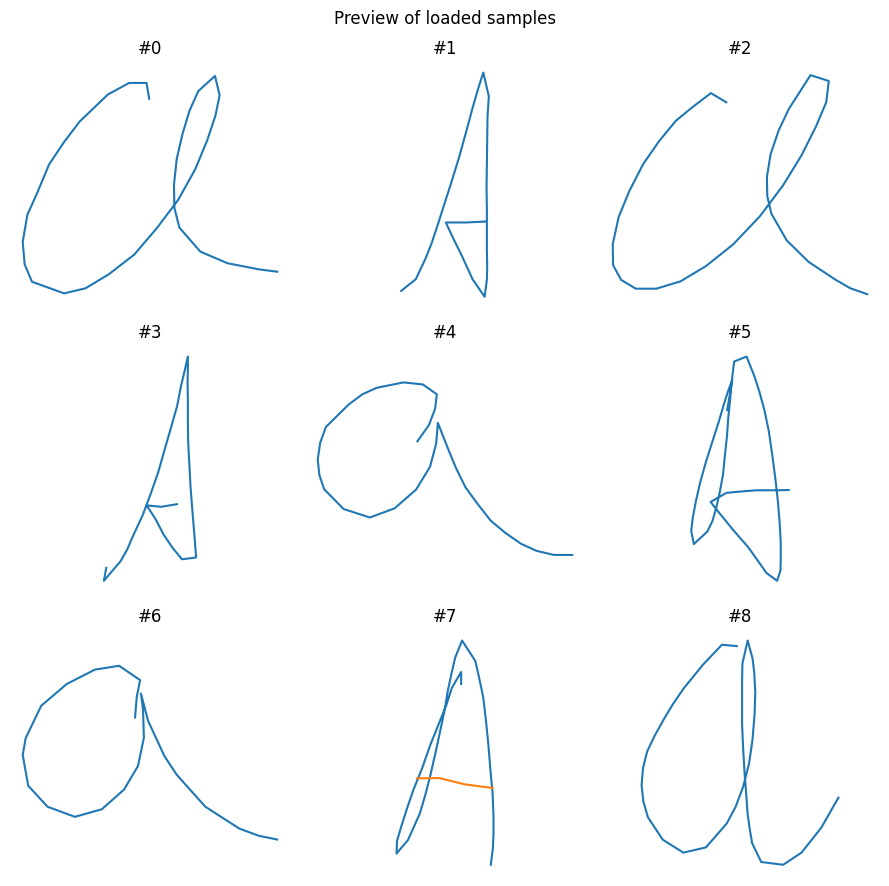

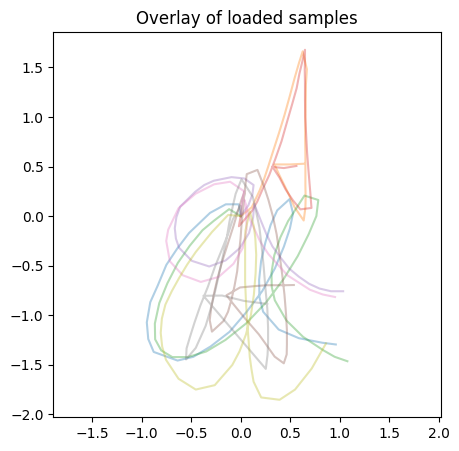

In [7]:

# -------------------------------------------------------
# experiment config
# -------------------------------------------------------
data_dir = Path(r"uji+pen+characters")

keep_labels = ["A"]       # e.g. ["A"] or ["A","B","C"] or None
use_delta = True

scenario = "overfit"      # "overfit" or "full"
sample_indices = range(0,44,2)      # used only when scenario == "overfit"
print(sample_indices)
repeats = 20             # used only when scenario == "overfit"

batch_size = 32
num_epochs = 2000
lr = 1e-3

# length model support
max_length_model = 50    # must be >= the actual lengths used after clamping

samples = load_uji_samples(
    data_dir=data_dir,
    keep_labels=keep_labels,
    use_delta=use_delta,
)

print("Loaded samples:", len(samples))
print("Labels present:", sorted(set(s["label"] for s in samples)))
print("First sample length:", len(samples[0]["sequence"]))

# optional dataset inspection
preview_indices = list(range(min(9, len(samples))))
preview_sequences = [samples[i]["sequence"] for i in preview_indices]
plot_multiple_sequences(preview_sequences, title="Preview of loaded samples", max_plots=9)
overlay_sequences(preview_sequences, title="Overlay of loaded samples")


Train dataset length: 440


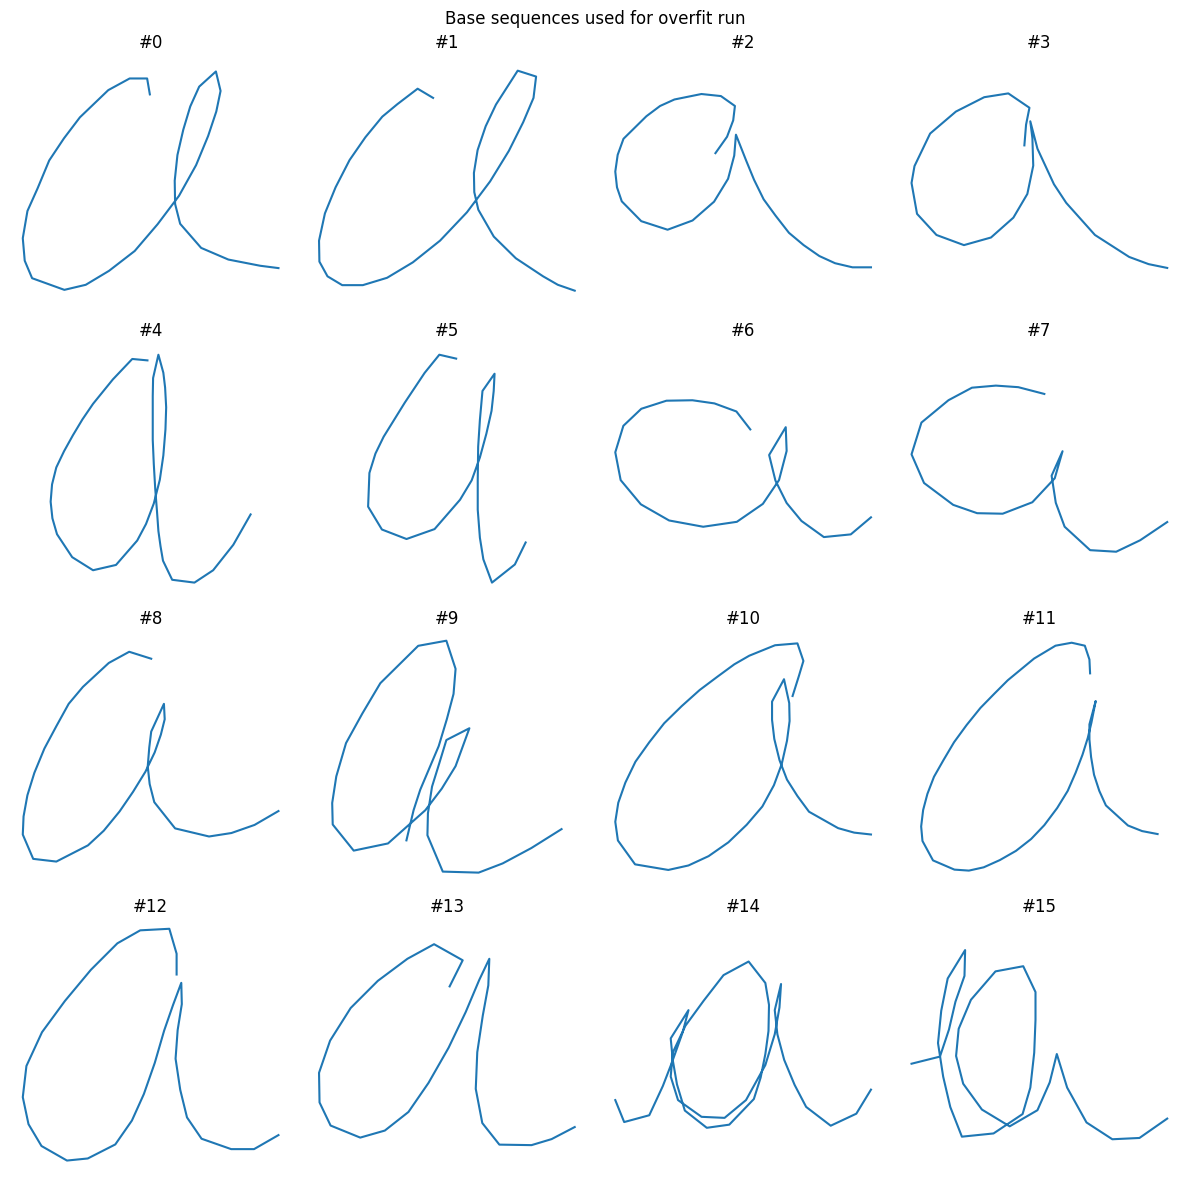

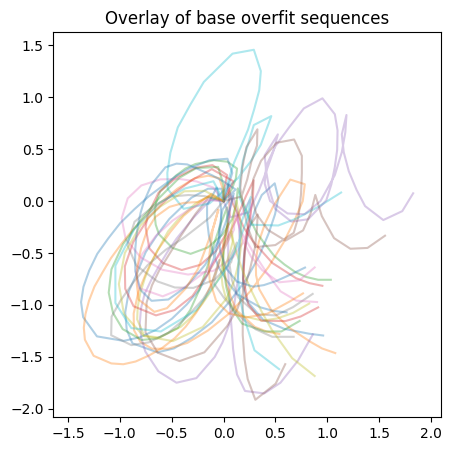

In [8]:

# -------------------------------------------------------
# build dataset / loader
# -------------------------------------------------------
if scenario == "overfit":
    train_dataset = RepeatedSubsetDataset(
        samples=samples,
        indices=sample_indices,
        repeats=repeats,
    )
else:
    train_dataset = UJIFullSequenceDataset(samples)

loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
)

print("Train dataset length:", len(train_dataset))

if scenario == "overfit":
    base_sequences = [train_dataset.get_base_sequence(i) for i in range(len(train_dataset.base_samples))]
    plot_multiple_sequences(base_sequences, title="Base sequences used for overfit run", max_plots=16)
    overlay_sequences(base_sequences, title="Overlay of base overfit sequences")


In [9]:

# -------------------------------------------------------
# stronger model:
# observed class y
# latent style s per sequence
# autoregressive latent z_t
# explicit global length model
# -------------------------------------------------------
class ClassStylePrior(nn.Module):
    def __init__(self, num_classes, class_emb_dim, style_dim, hidden_dim):
        super().__init__()
        self.class_emb = nn.Embedding(num_classes, class_emb_dim)
        self.net = nn.Sequential(
            nn.Linear(class_emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.loc_head = nn.Linear(hidden_dim, style_dim)
        self.scale_head = nn.Linear(hidden_dim, style_dim)

    def forward(self, y):
        y_emb = self.class_emb(y)
        h = self.net(y_emb)
        loc = self.loc_head(h)
        scale = F.softplus(self.scale_head(h)) + 1e-4
        return loc, scale, y_emb


class LengthNet(nn.Module):
    def __init__(self, class_emb_dim, style_dim, hidden_dim, max_length_model):
        super().__init__()
        self.max_length_model = max_length_model
        self.net = nn.Sequential(
            nn.Linear(class_emb_dim + style_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, max_length_model),
        )

    def forward(self, y_emb, s):
        inp = torch.cat([y_emb, s], dim=-1)
        return self.net(inp)


class InitialZNet(nn.Module):
    def __init__(self, class_emb_dim, style_dim, z_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(class_emb_dim + style_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.loc_head = nn.Linear(hidden_dim, z_dim)
        self.scale_head = nn.Linear(hidden_dim, z_dim)

    def forward(self, y_emb, s):
        inp = torch.cat([y_emb, s], dim=-1)
        h = self.net(inp)
        loc = self.loc_head(h)
        scale = F.softplus(self.scale_head(h)) + 1e-4
        return loc, scale


class TransitionNet(nn.Module):
    def __init__(self, x_dim, z_dim, class_emb_dim, style_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim + x_dim + class_emb_dim + style_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.loc_head = nn.Linear(hidden_dim, z_dim)
        self.scale_head = nn.Linear(hidden_dim, z_dim)

    def forward(self, z_prev, x_prev, y_emb, s):
        inp = torch.cat([z_prev, x_prev, y_emb, s], dim=-1)
        h = self.net(inp)
        loc = self.loc_head(h)
        scale = F.softplus(self.scale_head(h)) + 1e-4
        return loc, scale


class EmissionNet(nn.Module):
    def __init__(self, z_dim, y_emb_dim, s_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim + y_emb_dim + s_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.dxdy_loc_head = nn.Linear(hidden_dim, 2)
        self.dxdy_scale_head = nn.Linear(hidden_dim, 2)
        self.pen_logit_head = nn.Linear(hidden_dim, 1)
        self.eos_logit_head = nn.Linear(hidden_dim, 1)

    def forward(self, z_t, y_emb, s):
        inp = torch.cat([z_t, y_emb, s], dim=-1)
        h = self.net(inp)

        dxdy_loc = self.dxdy_loc_head(h)

        # IMPORTANT: scale must come from the 2D scale head, not from h
        dxdy_scale_raw = self.dxdy_scale_head(h)

        # bounded scale for stability
        dxdy_scale = 0.01 + 0.05 * torch.sigmoid(dxdy_scale_raw)

        pen_logits = self.pen_logit_head(h).squeeze(-1)
        eos_logits = self.eos_logit_head(h).squeeze(-1)

        return dxdy_loc, dxdy_scale, pen_logits, eos_logits

class StyleGuide(nn.Module):
    def __init__(self, x_dim, num_classes, class_emb_dim, style_dim, rnn_hidden_dim, hidden_dim):
        super().__init__()
        self.class_emb = nn.Embedding(num_classes, class_emb_dim)
        self.gru = nn.GRU(
            input_size=x_dim + class_emb_dim,
            hidden_size=rnn_hidden_dim,
            batch_first=True,
            bidirectional=True
        )
        self.net = nn.Sequential(
            nn.Linear(2 * rnn_hidden_dim + class_emb_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.loc_head = nn.Linear(hidden_dim, style_dim)
        self.scale_head = nn.Linear(hidden_dim, style_dim)

    def forward(self, x_tgt, y):
        B, T, _ = x_tgt.shape
        y_emb = self.class_emb(y)
        y_rep = y_emb.unsqueeze(1).expand(B, T, -1)
        h, _ = self.gru(torch.cat([x_tgt, y_rep], dim=-1))
        h_last = h[:, -1]
        g = self.net(torch.cat([h_last, y_emb], dim=-1))
        loc = self.loc_head(g)
        scale = F.softplus(self.scale_head(g)) + 1e-4
        return loc, scale, y_emb


class LocalGuide(nn.Module):
    def __init__(self, x_dim, class_emb_dim, style_dim, z_dim, rnn_hidden_dim):
        super().__init__()
        self.gru = nn.GRU(
            input_size=x_dim + class_emb_dim + style_dim,
            hidden_size=rnn_hidden_dim,
            batch_first=True
        )
        self.loc_head = nn.Linear(rnn_hidden_dim, z_dim)
        self.scale_head = nn.Linear(rnn_hidden_dim, z_dim)

    def forward(self, x_tgt, y_emb, s):
        B, T, _ = x_tgt.shape
        y_rep = y_emb.unsqueeze(1).expand(B, T, -1)
        s_rep = s.unsqueeze(1).expand(B, T, -1)
        h, _ = self.gru(torch.cat([x_tgt, y_rep, s_rep], dim=-1))
        loc = self.loc_head(h)
        scale = F.softplus(self.scale_head(h)) + 1e-4
        return loc, scale


class BetterCharacterModel(PyroModule):
    def __init__(
        self,
        num_classes,
        x_dim=4,
        z_dim=32,
        style_dim=16,
        class_emb_dim=12,
        hidden_dim=64,
        rnn_hidden_dim=64,
        max_length_model=128,
    ):
        super().__init__()
        self.num_classes = num_classes
        self.x_dim = x_dim
        self.z_dim = z_dim
        self.style_dim = style_dim
        self.max_length_model = max_length_model

        self.style_prior = ClassStylePrior(num_classes, class_emb_dim, style_dim, hidden_dim)
        self.length_net = LengthNet(class_emb_dim, style_dim, hidden_dim, max_length_model)
        self.init_z_net = InitialZNet(class_emb_dim, style_dim, z_dim, hidden_dim)
        self.transition_net = TransitionNet(x_dim, z_dim, class_emb_dim, style_dim, hidden_dim)
        self.emission_net = EmissionNet(z_dim, class_emb_dim, style_dim, hidden_dim)

        self.style_guide = StyleGuide(x_dim, num_classes, class_emb_dim, style_dim, rnn_hidden_dim, hidden_dim)
        self.local_guide = LocalGuide(x_dim, class_emb_dim, style_dim, z_dim, rnn_hidden_dim)

    def model(self, x_prev, x_tgt, lengths, y_obs):
        pyro.module("better_character_model", self)

        B, T, _ = x_tgt.shape
        device = x_tgt.device

        with pyro.plate("batch", B):
            style_loc, style_scale, y_emb = self.style_prior(y_obs)
            s = pyro.sample("s", dist.Normal(style_loc, style_scale).to_event(1))

            length_logits = self.length_net(y_emb, s)
            length_obs = torch.clamp(lengths, min=1, max=self.max_length_model) - 1
            pyro.sample("L", dist.Categorical(logits=length_logits), obs=length_obs)

            z_prev = None
            for t in pyro.markov(range(T)):
                mask_t = lengths > t

                if t == 0:
                    loc, scale = self.init_z_net(y_emb, s)
                else:
                    loc, scale = self.transition_net(z_prev, x_prev[:, t], y_emb, s)

                with poutine.mask(mask=mask_t):
                    z_t = pyro.sample(f"z_{t}", dist.Normal(loc, scale).to_event(1))

                    dxdy_loc, dxdy_scale, pen_logits, eos_logits = self.emission_net(z_t, y_emb, s)
                    pyro.sample(f"dxdy_{t}", dist.Normal(dxdy_loc, dxdy_scale).to_event(1), obs=x_tgt[:, t, :2])
                    pyro.sample(f"pen_{t}", dist.Bernoulli(logits=pen_logits), obs=x_tgt[:, t, 2])
                    pyro.sample(f"eos_{t}", dist.Bernoulli(logits=eos_logits), obs=x_tgt[:, t, 3])

                z_prev = z_t

    def guide(self, x_prev, x_tgt, lengths, y_obs):
        pyro.module("better_character_model", self)

        B, T, _ = x_tgt.shape

        with pyro.plate("batch", B):
            s_loc, s_scale, y_emb = self.style_guide(x_tgt, y_obs)
            s = pyro.sample("s", dist.Normal(s_loc, s_scale).to_event(1))

            z_loc, z_scale = self.local_guide(x_tgt, y_emb, s)

            for t in pyro.markov(range(T)):
                mask_t = lengths > t
                with poutine.mask(mask=mask_t):
                    pyro.sample(f"z_{t}", dist.Normal(z_loc[:, t], z_scale[:, t]).to_event(1))

    @torch.no_grad()
    def infer_style(self, seq, class_idx):
        self.eval()
        device = next(self.parameters()).device
        if seq.ndim != 2 or seq.shape[1] != self.x_dim:
            raise ValueError(f"seq must have shape [T, {self.x_dim}]")
        x = seq.unsqueeze(0).to(device)
        y = torch.tensor([class_idx], dtype=torch.long, device=device)
        s_loc, s_scale, y_emb = self.style_guide(x, y)
        return s_loc.squeeze(0), y_emb.squeeze(0)

    @torch.no_grad()
    def _infer_last_z(self, seq, class_idx, s=None, y_emb=None):
        self.eval()
        device = next(self.parameters()).device
        x = seq.unsqueeze(0).to(device)
        y = torch.tensor([class_idx], dtype=torch.long, device=device)

        if s is None or y_emb is None:
            s_loc, _, y_emb_batch = self.style_guide(x, y)
            s = s_loc
            y_emb = y_emb_batch
        else:
            s = s.unsqueeze(0).to(device)
            y_emb = y_emb.unsqueeze(0).to(device)

        z_loc, _ = self.local_guide(x, y_emb, s)
        return z_loc[:, -1], s.squeeze(0), y_emb.squeeze(0)

    @torch.no_grad()
    def predict_next_params(self, prefix_seq, class_idx):
        self.eval()
        device = next(self.parameters()).device

        if prefix_seq.ndim != 2 or prefix_seq.shape[1] != self.x_dim:
            raise ValueError(f"prefix_seq must have shape [T, {self.x_dim}]")
        if len(prefix_seq) < 1:
            raise ValueError("Need at least one observed point.")

        z_last, s, y_emb = self._infer_last_z(prefix_seq, class_idx)
        x_last = prefix_seq[-1].unsqueeze(0).to(device)
        loc, scale = self.transition_net(z_last, x_last, y_emb.unsqueeze(0), s.unsqueeze(0))
        z_next = loc  # deterministic next-state estimate for prediction
        dxdy_loc, dxdy_scale, pen_logits, eos_logits = self.emission_net(z_next, y_emb.unsqueeze(0), s.unsqueeze(0))

        length_logits = self.length_net(y_emb.unsqueeze(0), s.unsqueeze(0))
        length_probs = torch.softmax(length_logits, dim=-1)

        return {
            "dxdy_loc": dxdy_loc.squeeze(0),
            "dxdy_scale": dxdy_scale.squeeze(0),
            "pen_logits": pen_logits.squeeze(0),
            "eos_logits": eos_logits.squeeze(0),
            "pen_prob": torch.sigmoid(pen_logits).squeeze(0),
            "eos_prob": torch.sigmoid(eos_logits).squeeze(0),
            "style": s,
            "length_probs": length_probs.squeeze(0),
        }

    @torch.no_grad()
    def predict_next(self, prefix_seq, class_idx, use_sampling=False):
        params = self.predict_next_params(prefix_seq, class_idx)

        if use_sampling:
            dxdy = dist.Normal(params["dxdy_loc"], params["dxdy_scale"]).sample()
            pen = dist.Bernoulli(logits=params["pen_logits"]).sample().view(1)
            eos = dist.Bernoulli(logits=params["eos_logits"]).sample().view(1)
        else:
            dxdy = params["dxdy_loc"]
            pen = (params["pen_prob"] >= 0.5).float().view(1)
            eos = (params["eos_prob"] >= 0.5).float().view(1)

        return torch.cat([dxdy, pen, eos], dim=0)

    @torch.no_grad()
    def rollout_from_prefix(self, prefix_seq, class_idx, rollout_steps=20, use_sampling=False):
        self.eval()
        device = next(self.parameters()).device
        current_seq = prefix_seq.clone().to(device)

        z_last, s, y_emb = self._infer_last_z(current_seq, class_idx)
        y_emb_batch = y_emb.unsqueeze(0)
        s_batch = s.unsqueeze(0)

        generated_steps = []
        x_last = current_seq[-1].unsqueeze(0).to(device)

        for _ in range(rollout_steps):
            loc, scale = self.transition_net(z_last, x_last, y_emb_batch, s_batch)
            if use_sampling:
                z_next = dist.Normal(loc, scale).sample()
            else:
                z_next = loc

            dxdy_loc, dxdy_scale, pen_logits, eos_logits = self.emission_net(z_next, y_emb_batch, s_batch)

            if use_sampling:
                dxdy = dist.Normal(dxdy_loc, dxdy_scale).sample().squeeze(0)
                pen = dist.Bernoulli(logits=pen_logits).sample().view(-1)
                eos = dist.Bernoulli(logits=eos_logits).sample().view(-1)
            else:
                dxdy = dxdy_loc.squeeze(0)
                pen = (torch.sigmoid(pen_logits) >= 0.5).float().view(-1)
                eos = (torch.sigmoid(eos_logits) >= 0.5).float().view(-1)

            next_step = torch.cat([dxdy, pen[:1], eos[:1]], dim=0)
            generated_steps.append(next_step)
            current_seq = torch.cat([current_seq, next_step.unsqueeze(0)], dim=0)

            z_last = z_next
            x_last = next_step.unsqueeze(0)

            if next_step[3].item() > 0.5:
                break

        if len(generated_steps) == 0:
            generated_seq = torch.zeros((0, 4), dtype=current_seq.dtype, device=device)
        else:
            generated_seq = torch.stack(generated_steps, dim=0)

        return current_seq, generated_seq

    @torch.no_grad()
    def generate(self, class_idx, max_steps=None, use_sampling=True, device=None):
        self.eval()
        if device is None:
            device = next(self.parameters()).device

        y = torch.tensor([class_idx], dtype=torch.long, device=device)
        style_loc, style_scale, y_emb = self.style_prior(y)
        s = dist.Normal(style_loc, style_scale).sample()

        length_logits = self.length_net(y_emb, s)
        sampled_length = dist.Categorical(logits=length_logits).sample().item() + 1
        if max_steps is not None:
            sampled_length = min(sampled_length, max_steps)

        out = []
        loc0, scale0 = self.init_z_net(y_emb, s)
        z_prev = dist.Normal(loc0, scale0).sample() if use_sampling else loc0
        dxdy_loc, dxdy_scale, pen_logits, eos_logits = self.emission_net(z_prev, y_emb, s)

        if use_sampling:
            dxdy = dist.Normal(dxdy_loc, dxdy_scale).sample().squeeze(0)
            pen = dist.Bernoulli(logits=pen_logits).sample().view(-1)
            eos = dist.Bernoulli(logits=eos_logits).sample().view(-1)
        else:
            dxdy = dxdy_loc.squeeze(0)
            pen = (torch.sigmoid(pen_logits) >= 0.5).float().view(-1)
            eos = (torch.sigmoid(eos_logits) >= 0.5).float().view(-1)

        x_prev = torch.cat([dxdy, pen[:1], eos[:1]], dim=0)
        out.append(x_prev.cpu())

        for t in range(1, sampled_length):
            loc, scale = self.transition_net(z_prev, x_prev.unsqueeze(0), y_emb, s)
            z_t = dist.Normal(loc, scale).sample() if use_sampling else loc

            dxdy_loc, dxdy_scale, pen_logits, eos_logits = self.emission_net(z_t, y_emb, s)

            if use_sampling:
                dxdy = dist.Normal(dxdy_loc, dxdy_scale).sample().squeeze(0)
                pen = dist.Bernoulli(logits=pen_logits).sample().view(-1)
                eos = dist.Bernoulli(logits=eos_logits).sample().view(-1)
            else:
                dxdy = dxdy_loc.squeeze(0)
                pen = (torch.sigmoid(pen_logits) >= 0.5).float().view(-1)
                eos = (torch.sigmoid(eos_logits) >= 0.5).float().view(-1)

            x_t = torch.cat([dxdy, pen[:1], eos[:1]], dim=0)
            out.append(x_t.cpu())

            z_prev = z_t
            x_prev = x_t

        if len(out) == 0:
            return torch.zeros((0, 4), dtype=torch.float32)

        # force EOS at final step for generated sequence consistency
        out[-1][-1] = 1.0
        return torch.stack(out, dim=0)

    @torch.no_grad()
    def reconstruct_teacher_forced(self, seq, class_idx):
        self.eval()
        preds = []
        for t in range(1, len(seq)):
            preds.append(self.predict_next(seq[:t], class_idx, use_sampling=False))
        if len(preds) == 0:
            return torch.zeros((0, self.x_dim), dtype=seq.dtype, device=seq.device)
        return torch.stack(preds, dim=0)


In [10]:

# -------------------------------------------------------
# model init
# -------------------------------------------------------
pyro.clear_param_store()

model = BetterCharacterModel(
    num_classes=NUM_CLASSES,
    x_dim=4,
    z_dim=32,
    style_dim=16,
    class_emb_dim=12,
    hidden_dim=64,
    rnn_hidden_dim=64,
    max_length_model=max_length_model,
).to(device)

optimizer = ClippedAdam({
    "lr": lr,
    "clip_norm": 5.0,
})

svi = SVI(model.model, model.guide, optimizer, loss=Trace_ELBO())

print(model)


BetterCharacterModel(
  (style_prior): ClassStylePrior(
    (class_emb): Embedding(35, 12)
    (net): Sequential(
      (0): Linear(in_features=12, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
    )
    (loc_head): Linear(in_features=64, out_features=16, bias=True)
    (scale_head): Linear(in_features=64, out_features=16, bias=True)
  )
  (length_net): LengthNet(
    (net): Sequential(
      (0): Linear(in_features=28, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=50, bias=True)
    )
  )
  (init_z_net): InitialZNet(
    (net): Sequential(
      (0): Linear(in_features=28, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
    )
    (loc_head): Linear(in_features=64, out_features=32, bias=True)
    (scale_he

In [11]:

# -------------------------------------------------------
# training loop
# -------------------------------------------------------
def train_epoch(model, loader, svi, device):
    model.train()
    total_loss = 0.0
    total_items = 0

    for x_prev, x_tgt, lengths, y in loader:
        x_prev = x_prev.to(device)
        x_tgt = x_tgt.to(device)
        lengths = lengths.to(device)
        y = y.to(device)

        loss = svi.step(x_prev, x_tgt, lengths, y)
        total_loss += loss
        total_items += x_prev.shape[0]

    return total_loss / max(total_items, 1)


train_losses = []

for epoch in range(1, num_epochs + 1):
    avg_loss = train_epoch(model, loader, svi, device)
    train_losses.append(avg_loss)

    if epoch == 1 or epoch % 50 == 0:
        print(f"Epoch {epoch:03d} | avg ELBO loss per sample: {avg_loss:.4f}")


Epoch 001 | avg ELBO loss per sample: 471.9532
Epoch 050 | avg ELBO loss per sample: -65.5023
Epoch 100 | avg ELBO loss per sample: -76.1482
Epoch 150 | avg ELBO loss per sample: -80.9042


KeyboardInterrupt: 

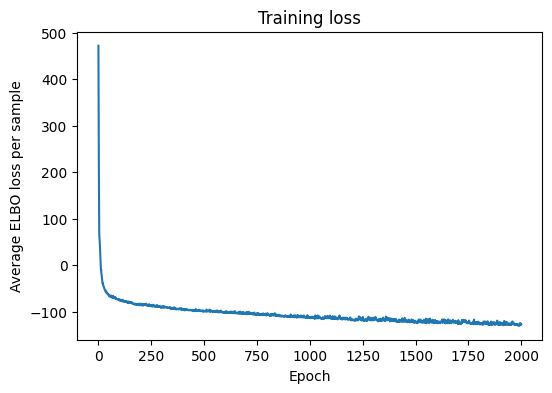

In [ ]:

plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Average ELBO loss per sample")
plt.title("Training loss")
plt.show()



## Standard evaluations

The cells below mirror the checks you were already using, but now with the stronger model.

- teacher-forced next-step
- rollout from real prefix
- pure ancestral samples
- generated length stats


Evaluation label: A
Sequence length: 34


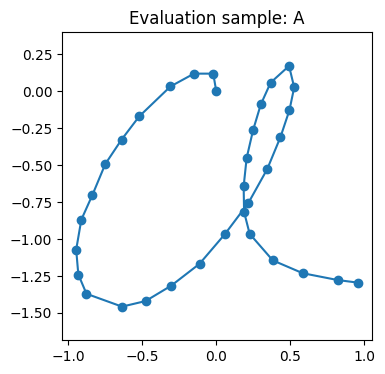

In [ ]:

# -------------------------------------------------------
# choose an evaluation sequence
# -------------------------------------------------------
if scenario == "overfit":
    sample_seq = train_dataset.get_base_sequence(0).to(device)
    sample_label = train_dataset.get_base_label(0)
else:
    sample_seq = torch.tensor(samples[0]["sequence"], dtype=torch.float32, device=device)
    sample_label = samples[0]["label"]

class_idx = class_to_idx[sample_label]

print("Evaluation label:", sample_label)
print("Sequence length:", len(sample_seq))
plot_sequence(sample_seq, title=f"Evaluation sample: {sample_label}")


Predicted next: [ 0.19573857 -0.20102972  1.          0.        ]
True next: [0.0144878 0.1680586 1.        0.       ]


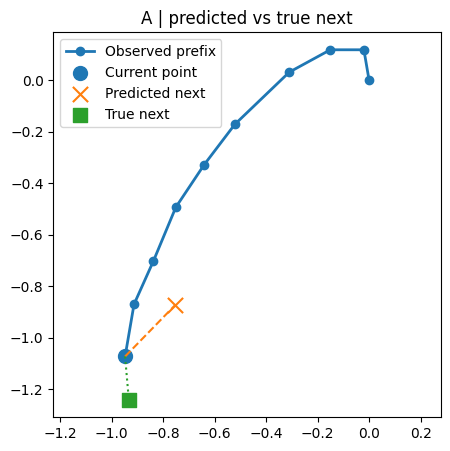

In [ ]:

# -------------------------------------------------------
# teacher-forced next-step prediction
# -------------------------------------------------------
prefix_len = min(10, len(sample_seq) - 1)
prefix = sample_seq[:prefix_len]
true_next = sample_seq[prefix_len]

next_pred = model.predict_next(prefix, class_idx, use_sampling=False)

print("Predicted next:", next_pred.detach().cpu().numpy())
print("True next:", true_next.detach().cpu().numpy())

plot_prefix_pred_and_true_next(
    prefix_seq=prefix,
    next_pred=next_pred,
    true_next=true_next,
    title=f"{sample_label} | predicted vs true next"
)


In [ ]:
sample_seq[1]

tensor([-0.0203, -0.1188,  1.0000,  0.0000])

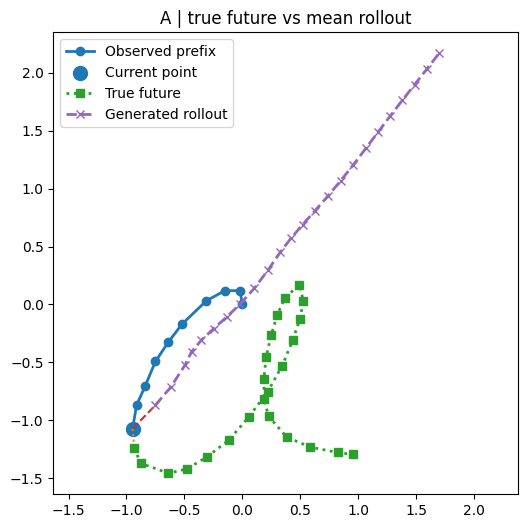

In [ ]:

# -------------------------------------------------------
# rollout from real prefix: mean rollout
# -------------------------------------------------------
prefix_len = min(10, len(sample_seq) - 1)
prefix = sample_seq[:prefix_len]
true_future = sample_seq[prefix_len:]

_, generated_seq = model.rollout_from_prefix(
    prefix_seq=prefix,
    class_idx=class_idx,
    rollout_steps=len(true_future),
    use_sampling=False,
)

plot_prefix_true_future_and_rollout(
    prefix_seq=prefix,
    true_future=true_future,
    generated_seq=generated_seq,
    title=f"{sample_label} | true future vs mean rollout"
)


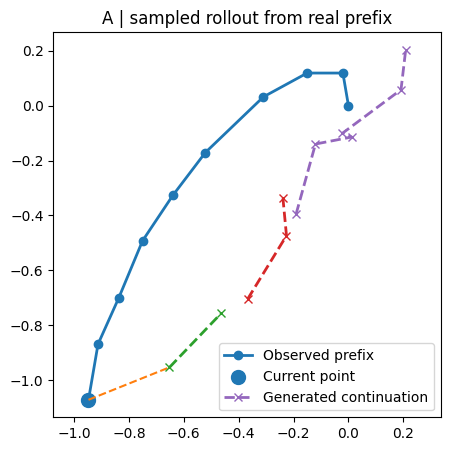

In [ ]:

# -------------------------------------------------------
# rollout from real prefix: sampled rollout
# -------------------------------------------------------
prefix_len = min(10, len(sample_seq) - 1)
prefix = sample_seq[:prefix_len]

_, generated_seq = model.rollout_from_prefix(
    prefix_seq=prefix,
    class_idx=class_idx,
    rollout_steps=25,
    use_sampling=True,
)

plot_prefix_and_rollout(
    prefix_seq=prefix,
    generated_seq=generated_seq,
    title=f"{sample_label} | sampled rollout from real prefix"
)


Sample 1: length = 28


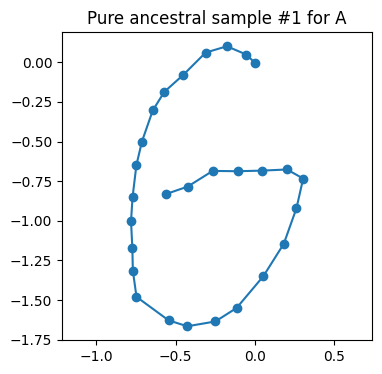

Sample 2: length = 28


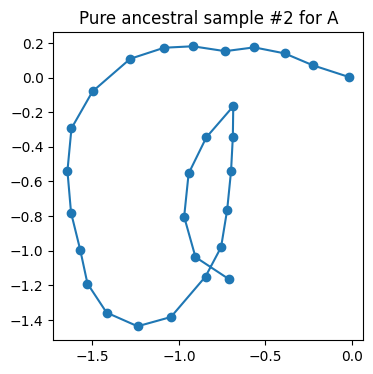

Sample 3: length = 34


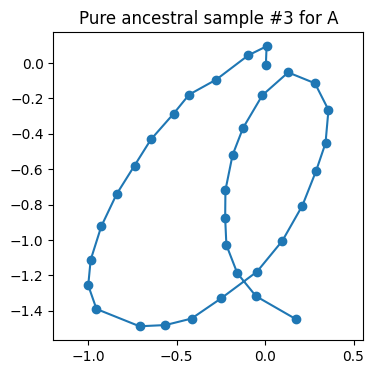

Sample 4: length = 21


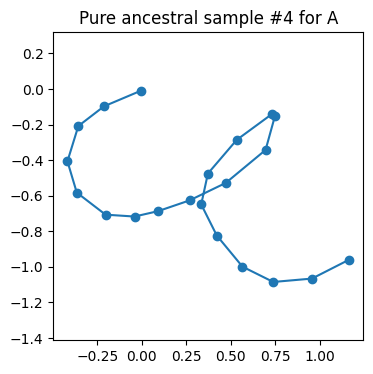

In [ ]:

# -------------------------------------------------------
# pure ancestral samples
# -------------------------------------------------------
label_to_generate = sample_label
class_idx = class_to_idx[label_to_generate]

for i in range(4):
    gen_seq = model.generate(
        class_idx=class_idx,
        max_steps=100,
        use_sampling=True,
        device=device,
    )
    print(f"Sample {i+1}: length = {len(gen_seq)}")
    plot_sequence(gen_seq, title=f"Pure ancestral sample #{i+1} for {label_to_generate}")


In [ ]:

# -------------------------------------------------------
# generated length statistics
# -------------------------------------------------------
label_to_generate = sample_label
class_idx = class_to_idx[label_to_generate]

lengths = []
for _ in range(50):
    gen_seq = model.generate(
        class_idx=class_idx,
        max_steps=100,
        use_sampling=True,
        device=device,
    )
    lengths.append(len(gen_seq))

print("Generated length stats")
print("min:", min(lengths))
print("max:", max(lengths))
print("mean:", sum(lengths) / len(lengths))
print("all:", lengths)


Generated length stats
min: 20
max: 41
mean: 29.58
all: [41, 34, 30, 21, 20, 28, 25, 41, 34, 30, 40, 31, 24, 41, 20, 41, 34, 25, 31, 37, 41, 22, 28, 20, 28, 28, 34, 20, 28, 28, 30, 28, 31, 22, 25, 40, 30, 34, 25, 31, 37, 28, 34, 20, 28, 28, 28, 20, 30, 25]


In [ ]:

# -------------------------------------------------------
# render PGM
# note: use an actual file extension
# -------------------------------------------------------
x_prev_small, x_tgt_small, lengths_small, y_small = next(iter(loader))

x_prev_small = x_prev_small[:1, :5].to(device)
x_tgt_small = x_tgt_small[:1, :5].to(device)
lengths_small = torch.clamp(lengths_small[:1], max=5).to(device)
y_small = y_small[:1].to(device)

graph = render_model(
    model.model,
    model_args=(x_prev_small, x_tgt_small, lengths_small, y_small),
    render_distributions=True,
    render_params=True,
    filename="better_character_model_graph.pdf",
)

print("Rendered graph to better_character_model_graph.pdf")


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH


## Notes

This model is stronger than the earlier unconditional overfit model because it explicitly includes:

- **class conditioning**
- **global latent style**
- **autoregressive transition**
- **global length model**

That does **not** guarantee great samples immediately. It just gives the model a better chance to represent the right structure.

What to try next:

1. `keep_labels=["A"]`, `scenario="overfit"`, `sample_indices=[0]`
2. then `sample_indices=[0,1]`
3. then `sample_indices=[0,1,2,3,4]`
4. only after that, try multiple labels

That progression is still the cleanest way to debug.
